In [213]:
import sys
sys.path.append("/home/wuhlmann/BA/repo/lamah-ce_lstm/analysis/CSA")

In [214]:
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np

from numpy.random import Generator, MT19937
from collections import Counter 
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score  

#plotting
from matplotlib.patches import Patch, Polygon
import matplotlib.pyplot as plt
import seaborn as sns
from cell_state_plotters import plot_cell_state_2d

#### Load data

In [215]:
strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [216]:
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]
lamah_gdf.sort_index(ascending=True, inplace=True)

In [217]:
with open("/home/wuhlmann/BA/data/processed_data/evaluation/q_pred_landcover_0903_135428_domain_metrics.p", "rb") as f: 
	domain_metrics = pickle.load(f)
	
for period in domain_metrics.keys():
	
	for basin_id in domain_metrics[period].keys():
		lamah_gdf.loc[int(basin_id), "period"] = period
		lamah_gdf.loc[int(basin_id), "NSE"] = domain_metrics[period][basin_id]["1D"]["NSE"]

### MDS of cell states

In [218]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states_mds.p", "rb") as f: 
	means_mds = pickle.load(f)

In [219]:
array = means_mds["non-metric"]["raw"]

In [220]:
rng_seed = 1277
rng = Generator(MT19937(rng_seed))

  1%|          | 1/100 [00:00<00:10,  9.89it/s]

100%|██████████| 100/100 [00:10<00:00,  9.73it/s]


Text(0.5, 1.0, 's_scores')

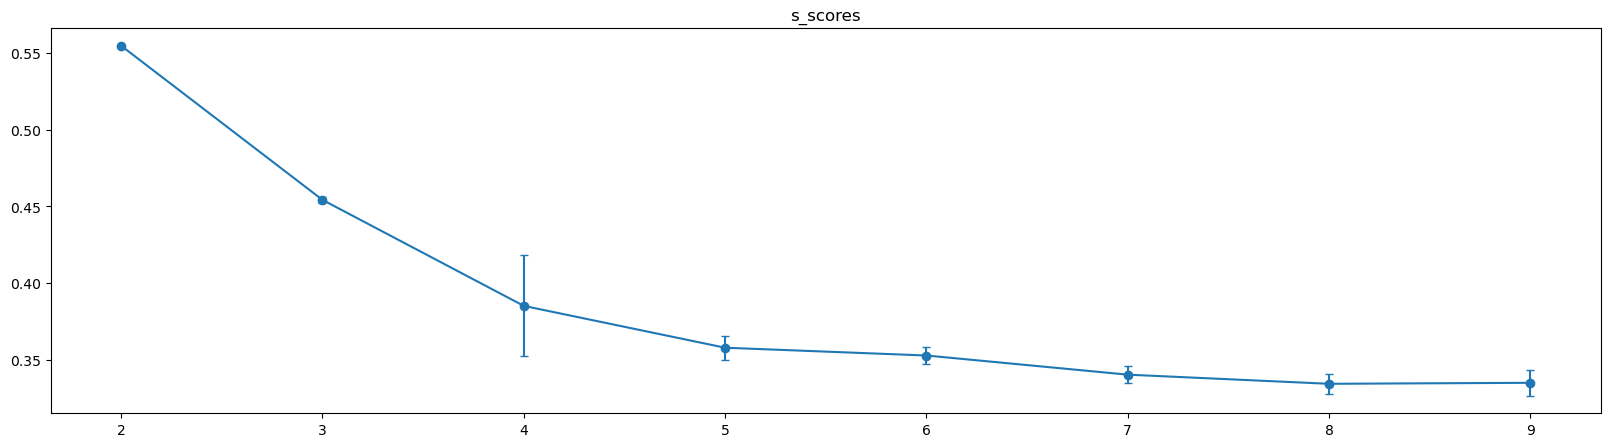

In [221]:
n_seeds = 100

seeds = list(rng.integers(0, 1000, n_seeds))
s_scores = np.zeros([n_seeds,10]) 

for i in tqdm(range(0,n_seeds)):

	seed = seeds[i]

	for k in range(2,10):

		# Test for k-means.
		labels = KMeans(k,random_state=seed).fit_predict(array)
		s_scores[i,k] = silhouette_score(array,labels) # higher is better
		
avg_s_scores = s_scores.mean(axis=0)[2:]

std_s_scores = s_scores.std(axis=0)[2:]

fig, axs = plt.subplots(1,1, figsize=(20,5))

axs.errorbar(range(2,10), avg_s_scores, yerr=std_s_scores, marker="o", capsize=3)

axs.set_title("s_scores")

#### Pinpoint basins in mds space

In [222]:
sep_transition_strata_ids = [759, 771, 740, 752, 670, 830, 822, 824, 823, 825]
positions = [lamah_gdf.index.get_loc(i) for i in sep_transition_strata_ids]
sep_mds_points =  array[positions, :]

In [223]:
lamah_gdf["mds1"] = array[:,0]
lamah_gdf["mds2"] = array[:,1]

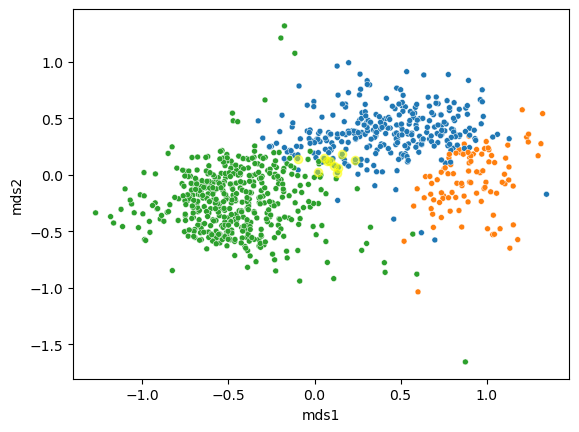

In [224]:
sns.scatterplot(data=lamah_gdf, x="mds1", y="mds2",hue=strata_colors, legend=False, size=0.5)
plt.scatter(x=sep_mds_points[:,0], y=sep_mds_points[:,1], color="yellow", alpha=0.5)

#### Plot mds space

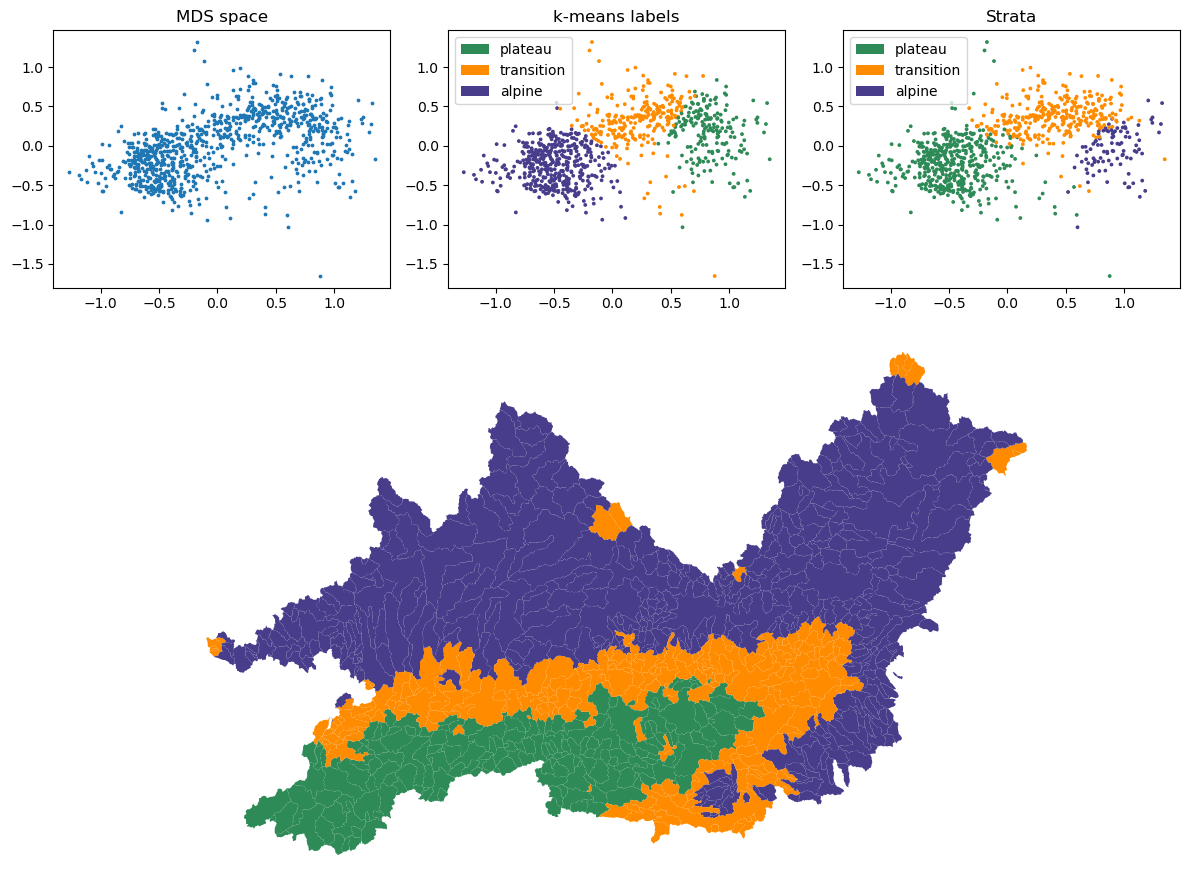

In [277]:
seed = 235 #seeds[np.where(s_scores[:,3] == Counter(s_scores[:,3]).most_common(1)[0][0])[0][0]] #235
k_means = KMeans(3, random_state=seed, max_iter=100)

fig, axs = plt.subplot_mosaic("ABC;DDD;DDD", figsize=(12,9))

#cluster = k_means.fit_predict(array)

# 1. remap 
label_dict = {0: 2, 1: 0, 2: 1}
cluster_remapped = list(map(lambda x: label_dict[x], cluster))

# 2. labels
name_dict = {0: "plateau", 1: "transition", 2: "alpine"}
cluster_named = list(map(lambda x: name_dict[x], cluster_remapped))

# 3. colors
color_dict = {"plateau": "seagreen", "transition": "darkorange", "alpine": "darkslateblue"}
cluster_colors = list(map(lambda x: color_dict[x], cluster_named))
strata_colors = list(map(lambda x: color_dict[name_dict[x]], strata_ids["0"]))

# GDF
lamah_gdf["cluster"] = cluster_named

s = 3
plot_cell_state_2d(array, ax=axs["A"], title="MDS space", s=s) 
plot_cell_state_2d(array, ax=axs["B"], title="k-means labels", c=cluster_colors, s=s) 
plot_cell_state_2d(array, ax=axs["C"], title="Strata", c=strata_colors, s=s, label=strata_colors)

legend_elements = [
    Patch(facecolor="seagreen",      label="plateau"),
    Patch(facecolor="darkorange",    label="transition"),
    Patch(facecolor="darkslateblue", label="alpine"),
]

axs["B"].legend(handles=legend_elements, loc="upper left")
axs["C"].legend(handles=legend_elements, loc="upper left")

lamah_gdf.plot(ax=axs["D"], color=lamah_gdf["cluster"].map(color_dict))
axs["D"].axis("off")

plt.tight_layout()
fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CSA/mds_2d.png", dpi=300)

In [269]:
print(f"jaccard score {jaccard_score(lamah_gdf['strata'], lamah_gdf['cluster'], average='weighted')}")

jaccard score 0.737714051952144


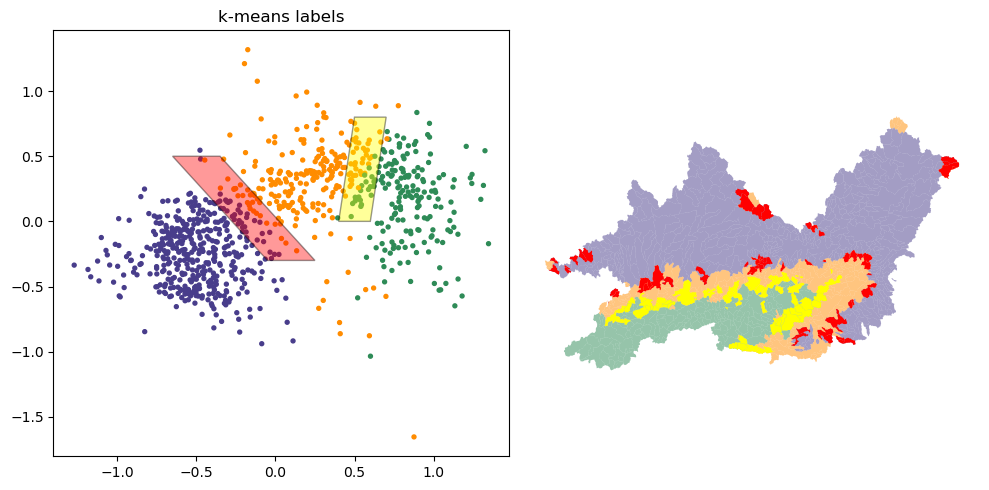

In [287]:

fig, axs = plt.subplot_mosaic("AB", figsize=(10,5))

plot_cell_state_2d(array, ax=axs["A"], title="k-means labels", c=cluster_colors, s=8) 

# Border plateau - transition
p1 = Polygon(xy=[(-0.65,0.5),(-0.35,0.5), (0.25,-0.3),(-0.05,-0.3)], facecolor="red", edgecolor="black", alpha=0.4)
axs["A"].add_patch(p1)
p2 = Polygon(xy=[(0.5,0.8),(0.7,0.8),(0.6,0.0), (0.4,0.0)], facecolor="yellow", edgecolor="black", alpha=0.4)
axs["A"].add_patch(p2)

border_basin_01_ids = lamah_gdf.index[p1.contains_points(p1.get_data_transform().transform(array))] 
border_basin_02_ids = lamah_gdf.index[p2.contains_points(p1.get_data_transform().transform(array))] 

lamah_gdf.plot(color=lamah_gdf["cluster"].map(color_dict), alpha=0.5,ax=axs["B"])
lamah_gdf.loc[border_basin_01_ids, :].plot(color="red", ax=axs["B"])
lamah_gdf.loc[border_basin_02_ids, :].plot(color="yellow", ax=axs["B"])
axs["B"].axis("off")

plt.tight_layout()
fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CSA/bordering_basins.png", dpi=300)

### Raw cell states

In [249]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states.p", "rb") as f: 
	raw_cell_states = pickle.load(f)

raw_cell_states = dict(sorted(raw_cell_states.items(), key=lambda item: int(item[0])))

In [250]:
r_cs_array = np.vstack([raw_cell_states[b]["c_mean"] for b in raw_cell_states.keys()])

100%|██████████| 100/100 [00:14<00:00,  6.75it/s]


Text(0.5, 1.0, 's_scores')

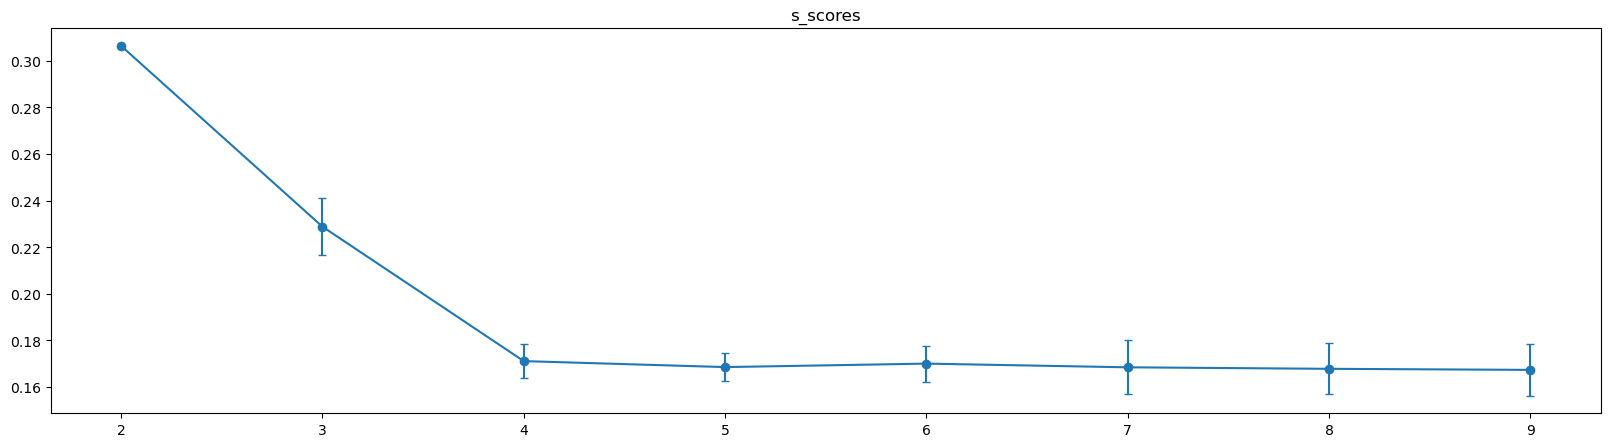

In [271]:
rng_seed = 1277
rng = Generator(MT19937(rng_seed))

n_seeds = 100

seeds = list(rng.integers(0, 1000, n_seeds))
s_scores_2 = np.zeros([n_seeds,10]) 

for i in tqdm(range(0,n_seeds)):

	seed = seeds[i]

	for k in range(2,10):

		# Test for k-means.
		labels = KMeans(k,random_state=seed).fit_predict(r_cs_array)
		s_scores[i,k] = silhouette_score(r_cs_array,labels) # higher is better
		
avg_s_scores = s_scores.mean(axis=0)[2:]

std_s_scores = s_scores.std(axis=0)[2:]

fig, axs = plt.subplots(1,1, figsize=(20,5))

axs.errorbar(range(2,10), avg_s_scores, yerr=std_s_scores, marker="o", capsize=3)

axs.set_title("s_scores")

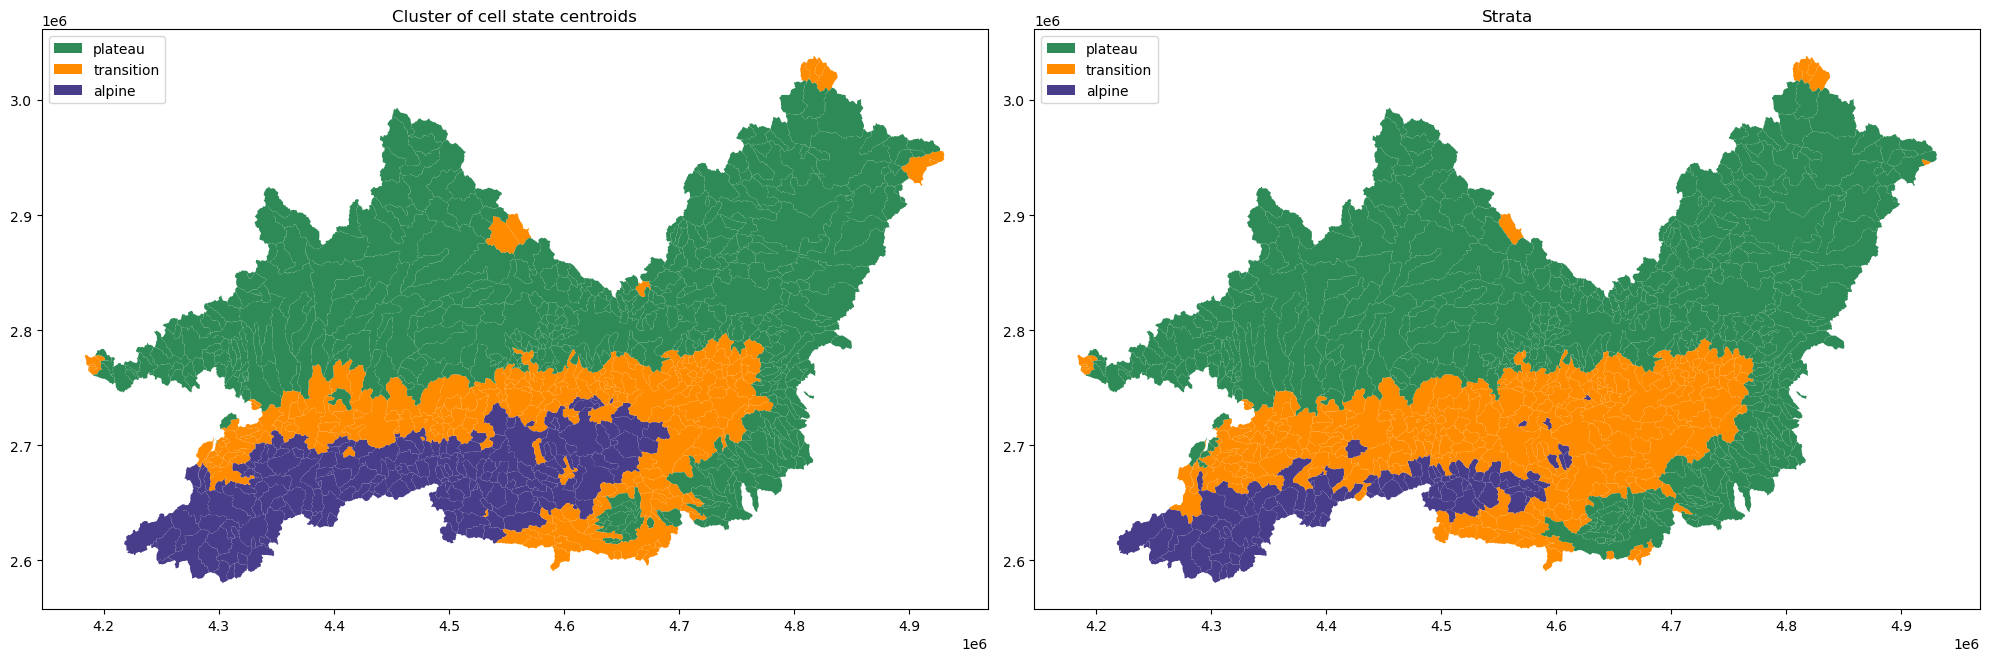

In [276]:
c = Counter(s_scores_2[:,3])

kmeans_seed = 774 #seeds[np.where(s_scores_2[:,3] == c.most_common(1)[0][0])[0][0]]

kmeans = KMeans(n_clusters=3, random_state=kmeans_seed, max_iter=100)

fig, axs = plt.subplots(1,2, figsize=(20,10))

cluster = kmeans.fit_predict(r_cs_array)

# 1. remap 
label_dict = {0: 0, 1: 2, 2: 1}
cluster_remapped = list(map(lambda x: label_dict[x], cluster))

# 2. labels
name_dict = {0: "plateau", 1: "transition", 2: "alpine"}
cluster_named = list(map(lambda x: name_dict[x], cluster_remapped))

lamah_gdf["cluster"] = cluster_named

lamah_gdf.plot(color=lamah_gdf["cluster"].map(color_dict), ax=axs[0], legend=True)
axs[0].set_title("Cluster of cell state centroids")
lamah_gdf.plot(color=strata_colors, ax=axs[1], legend=True)
axs[1].set_title("Strata")

axs[0].legend(handles=legend_elements, loc="upper left")
axs[1].legend(handles=legend_elements, loc="upper left")

plt.tight_layout()

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CSA/cluster_centroids_strata_map.png", dpi=300)

In [275]:
from sklearn.metrics import jaccard_score

print(f"jaccard score {jaccard_score(lamah_gdf['strata'], lamah_gdf['cluster'], average='weighted')}")


jaccard score 0.7704410139981576
